# Jalon 4 — comparaison CAM mobile vs Grad-CAM Keras

Objectif : vérifier si l'explication affichée dans l'application mobile ressemble au Grad-CAM calculé côté Python/Keras.

L'application mobile ne calcule pas un vrai Grad-CAM avec gradients, car TFLite/Flutter ne fournit pas `GradientTape`. Elle utilise une approximation de type CAM :

- le TFLite exporte les probabilités et les features `conv_1` de MobileNetV3Small ;
- l'app combine ces features avec les poids de la couche Dense finale ;
- la carte obtenue est normalisée puis agrandie en 224x224.

Ce notebook compare donc, sur les mêmes images :

1. la prédiction Keras ;
2. la prédiction TFLite mobile ;
3. la CAM mobile reconstruite en Python depuis le TFLite et les poids embarqués ;
4. la CAM Keras équivalente, calculée depuis les features Keras et les poids Dense ;
5. le vrai Grad-CAM Keras avec `GradientTape` softmax ;
6. un Grad-CAM Keras basé sur le logit pré-softmax.


In [1]:
from pathlib import Path
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

import tensorflow as tf

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

MODEL_PATH = ROOT / 'models' / 'jalon4_original_segmented_plantdoc_ft.keras'
TFLITE_PATH = ROOT / 'mobile' / 'assets' / 'models' / 'agroscan_baseline_float.tflite'
LABELS_PATH = ROOT / 'mobile' / 'assets' / 'models' / 'labels.json'
WEIGHTS_PATH = ROOT / 'mobile' / 'assets' / 'models' / 'gradcam_classifier_weights.bin'
WEIGHTS_META_PATH = ROOT / 'mobile' / 'assets' / 'models' / 'gradcam_classifier_weights.json'
PLANTDOC_TEST = ROOT / 'data' / 'plantdoc' / 'test'
REPORT_DIR = ROOT / 'reports'
REPORT_DIR.mkdir(exist_ok=True)

IMG_SIZE = (224, 224)
SEED = 42
rng = np.random.default_rng(SEED)

print('Keras model:', MODEL_PATH)
print('TFLite model:', TFLITE_PATH)
print('PlantDoc test:', PLANTDOC_TEST)


I0000 00:00:1780244194.723419   18304 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780244195.274888   18304 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Keras model: /home/leonard/UQAC/8INF934 - Atelier Pratique IA I/Projet/AgroScan/models/jalon4_original_segmented_plantdoc_ft.keras
TFLite model: /home/leonard/UQAC/8INF934 - Atelier Pratique IA I/Projet/AgroScan/mobile/assets/models/agroscan_baseline_float.tflite
PlantDoc test: /home/leonard/UQAC/8INF934 - Atelier Pratique IA I/Projet/AgroScan/data/plantdoc/test


## 1. Chargement du modèle et des assets mobile

In [2]:
labels = json.loads(LABELS_PATH.read_text(encoding='utf-8'))
weights_meta = json.loads(WEIGHTS_META_PATH.read_text(encoding='utf-8'))
mobile_weights = np.fromfile(WEIGHTS_PATH, dtype=np.float32).reshape(
    weights_meta['channels'], weights_meta['classes']
)

model = tf.keras.models.load_model(MODEL_PATH, compile=False)
interpreter = tf.lite.Interpreter(model_path=str(TFLITE_PATH))
interpreter.allocate_tensors()

input_detail = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()
class_output = next(
    out for out in output_details
    if len(out['shape']) == 2 and int(out['shape'][-1]) == len(labels)
)
conv_output = next(
    out for out in output_details
    if len(out['shape']) == 4 and int(out['shape'][1]) == 7 and int(out['shape'][2]) == 7
)

print('source_keras mobile:', weights_meta.get('source_keras'))
print('TFLite input:', input_detail['shape'], input_detail['dtype'])
print('TFLite class output:', class_output['name'], class_output['shape'])
print('TFLite conv output:', conv_output['name'], conv_output['shape'])
print('Dense weights:', mobile_weights.shape)


W0000 00:00:1780244195.780185   18304 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1780244195.785042   18304 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


source_keras mobile: jalon4_original_segmented_plantdoc_ft.keras
TFLite input: [  1 224 224   3] <class 'numpy.float32'>
TFLite class output: StatefulPartitionedCall_1:1 [ 1 38]
TFLite conv output: StatefulPartitionedCall_1:0 [  1   7   7 576]
Dense weights: (576, 38)


/home/leonard/UQAC/8INF934 - Atelier Pratique IA I/Projet/AgroScan/.venv/lib/python3.11/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


## 2. Fonctions de prédiction et de cartes d'attention

In [3]:
def load_image_array(path: Path) -> np.ndarray:
    image = ImageOps.exif_transpose(Image.open(path)).convert('RGB')
    image = image.resize(IMG_SIZE, Image.Resampling.BILINEAR)
    return np.asarray(image, dtype=np.float32)


def run_keras(image_224: np.ndarray) -> np.ndarray:
    return model.predict(image_224[None, ...], verbose=0)[0]


def run_tflite(image_224: np.ndarray):
    x = image_224.astype(np.float32)[None, ...]
    interpreter.set_tensor(input_detail['index'], x)
    interpreter.invoke()
    probs = interpreter.get_tensor(class_output['index'])[0]
    conv = interpreter.get_tensor(conv_output['index'])[0]
    return probs, conv


def normalize_heatmap(h: np.ndarray) -> np.ndarray:
    h = np.maximum(h, 0)
    max_val = float(h.max())
    if max_val > 0:
        h = h / max_val
    return h.astype(np.float32)


def mobile_cam_from_conv(conv_features: np.ndarray, class_index: int) -> np.ndarray:
    # Même logique que mobile/lib/data/ml/grad_cam.dart : ReLU(sum_c A_k * W_k,class).
    heat7 = np.tensordot(conv_features, mobile_weights[:, class_index], axes=([2], [0]))
    return normalize_heatmap(heat7)


def keras_cam_from_conv(conv_features: np.ndarray, class_index: int) -> np.ndarray:
    # CAM équivalente côté Keras, avec les features Keras et le kernel Dense Keras.
    kernel, _bias = final_dense.get_weights()
    heat7 = np.tensordot(conv_features, kernel[:, class_index], axes=([2], [0]))
    return normalize_heatmap(heat7)


def upsample_heatmap(heatmap: np.ndarray, size=IMG_SIZE) -> np.ndarray:
    return tf.image.resize(heatmap[..., None], size, method='bilinear').numpy().squeeze()


# Grad-CAM Keras : gradient du score de classe par rapport à conv_1.
# Le backbone MobileNetV3Small est imbriqué dans le modèle complet, donc on
# construit un sous-modèle qui sort à la fois conv_1 et les features finales.
backbone = model.layers[1]
backbone_grad_model = tf.keras.Model(
    inputs=backbone.input,
    outputs=[backbone.get_layer('conv_1').output, backbone.output],
)
head_layers = model.layers[2:]
final_dense = next(layer for layer in reversed(head_layers) if isinstance(layer, tf.keras.layers.Dense))


def classifier_head(features: tf.Tensor, training: bool = False, logits: bool = False) -> tf.Tensor:
    x = features
    for layer in head_layers:
        if layer is final_dense and logits:
            kernel, bias = layer.get_weights()
            x = tf.linalg.matmul(x, tf.convert_to_tensor(kernel, dtype=x.dtype))
            x = tf.nn.bias_add(x, tf.convert_to_tensor(bias, dtype=x.dtype))
        elif isinstance(layer, tf.keras.layers.Dropout):
            x = layer(x, training=training)
        else:
            x = layer(x)
    return x


def keras_conv_and_predictions(image_224: np.ndarray):
    x = tf.convert_to_tensor(image_224[None, ...], dtype=tf.float32)
    conv_outputs, features = backbone_grad_model(x, training=False)
    predictions = classifier_head(features, training=False, logits=False)
    logits = classifier_head(features, training=False, logits=True)
    return conv_outputs[0].numpy(), predictions.numpy()[0], logits.numpy()[0]


def keras_gradcam(image_224: np.ndarray, class_index: int, logits: bool = False) -> np.ndarray:
    x = tf.convert_to_tensor(image_224[None, ...], dtype=tf.float32)
    with tf.GradientTape() as tape:
        conv_outputs, features = backbone_grad_model(x, training=False)
        scores = classifier_head(features, training=False, logits=logits)
        class_score = scores[:, class_index]
    grads = tape.gradient(class_score, conv_outputs)
    if grads is None:
        raise RuntimeError('GradientTape returned None for conv_1 outputs')
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
    return normalize_heatmap(heatmap.numpy())


def heatmap_metrics(a: np.ndarray, b: np.ndarray) -> dict:
    a = upsample_heatmap(a).reshape(-1)
    b = upsample_heatmap(b).reshape(-1)
    eps = 1e-8
    corr = np.corrcoef(a, b)[0, 1] if np.std(a) > eps and np.std(b) > eps else np.nan
    mae = float(np.mean(np.abs(a - b)))
    # Overlap des 20% pixels les plus chauds.
    qa = np.quantile(a, 0.80)
    qb = np.quantile(b, 0.80)
    ma = a >= qa
    mb = b >= qb
    iou20 = float((ma & mb).sum() / ((ma | mb).sum() + eps))
    return {'corr': float(corr), 'mae': mae, 'top20_iou': iou20}


## 3. Sélection d'un petit échantillon PlantDoc

On prend quelques images de classes différentes pour avoir une lecture qualitative variée. Vous pouvez remplacer `sample_paths` par une liste manuelle si vous voulez inspecter des cas précis.

In [4]:
all_images = sorted(
    [p for p in PLANTDOC_TEST.glob('*/*') if p.suffix.lower() in {'.jpg', '.jpeg', '.png'}]
)
classes = sorted({p.parent.name for p in all_images})

sample_paths = []
for cls in classes:
    cls_images = [p for p in all_images if p.parent.name == cls]
    if cls_images:
        sample_paths.append(cls_images[int(rng.integers(0, len(cls_images)))])

# Échantillon limité pour un affichage lisible.
sample_paths = sample_paths[:12]
print(f'{len(sample_paths)} images sélectionnées')
for p in sample_paths:
    print('-', p.parent.name, '/', p.name)


12 images sélectionnées
- Apple Scab Leaf / 052609%20Hartman%20Crabapple%20scab%20single%20leaf.JPG.jpg
- Apple leaf / apple-leaf-9834637.jpg
- Apple rust leaf / 20130802_111632.jpg
- Bell_pepper leaf / IMG_1629.JPG?1507122477.jpg
- Bell_pepper leaf spot / Bacterial-spot-pepper2.jpg
- Blueberry leaf / vaccinium-angustifolium-low-bush-blueberry_0830_124221.jpg
- Cherry leaf / d7b79dbc0bca0eb3e63fbe5dfb256ccd53d90a4eb1413_1260x1260.jpg
- Corn Gray leaf spot / show_picture.asp?id=aaaaaaaaaaogcqq&w2=420&h2=378&clip=center,420,378&meta=0.jpg
- Corn leaf blight / 07c.jpg
- Corn rust leaf / 0796.39maizerust.jpg
- Peach leaf / peach-leaf-16690421.jpg
- Potato leaf early blight / potatobd001.jpg


## 4. Comparaison visuelle

E0000 00:00:1780244198.090994   18460 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


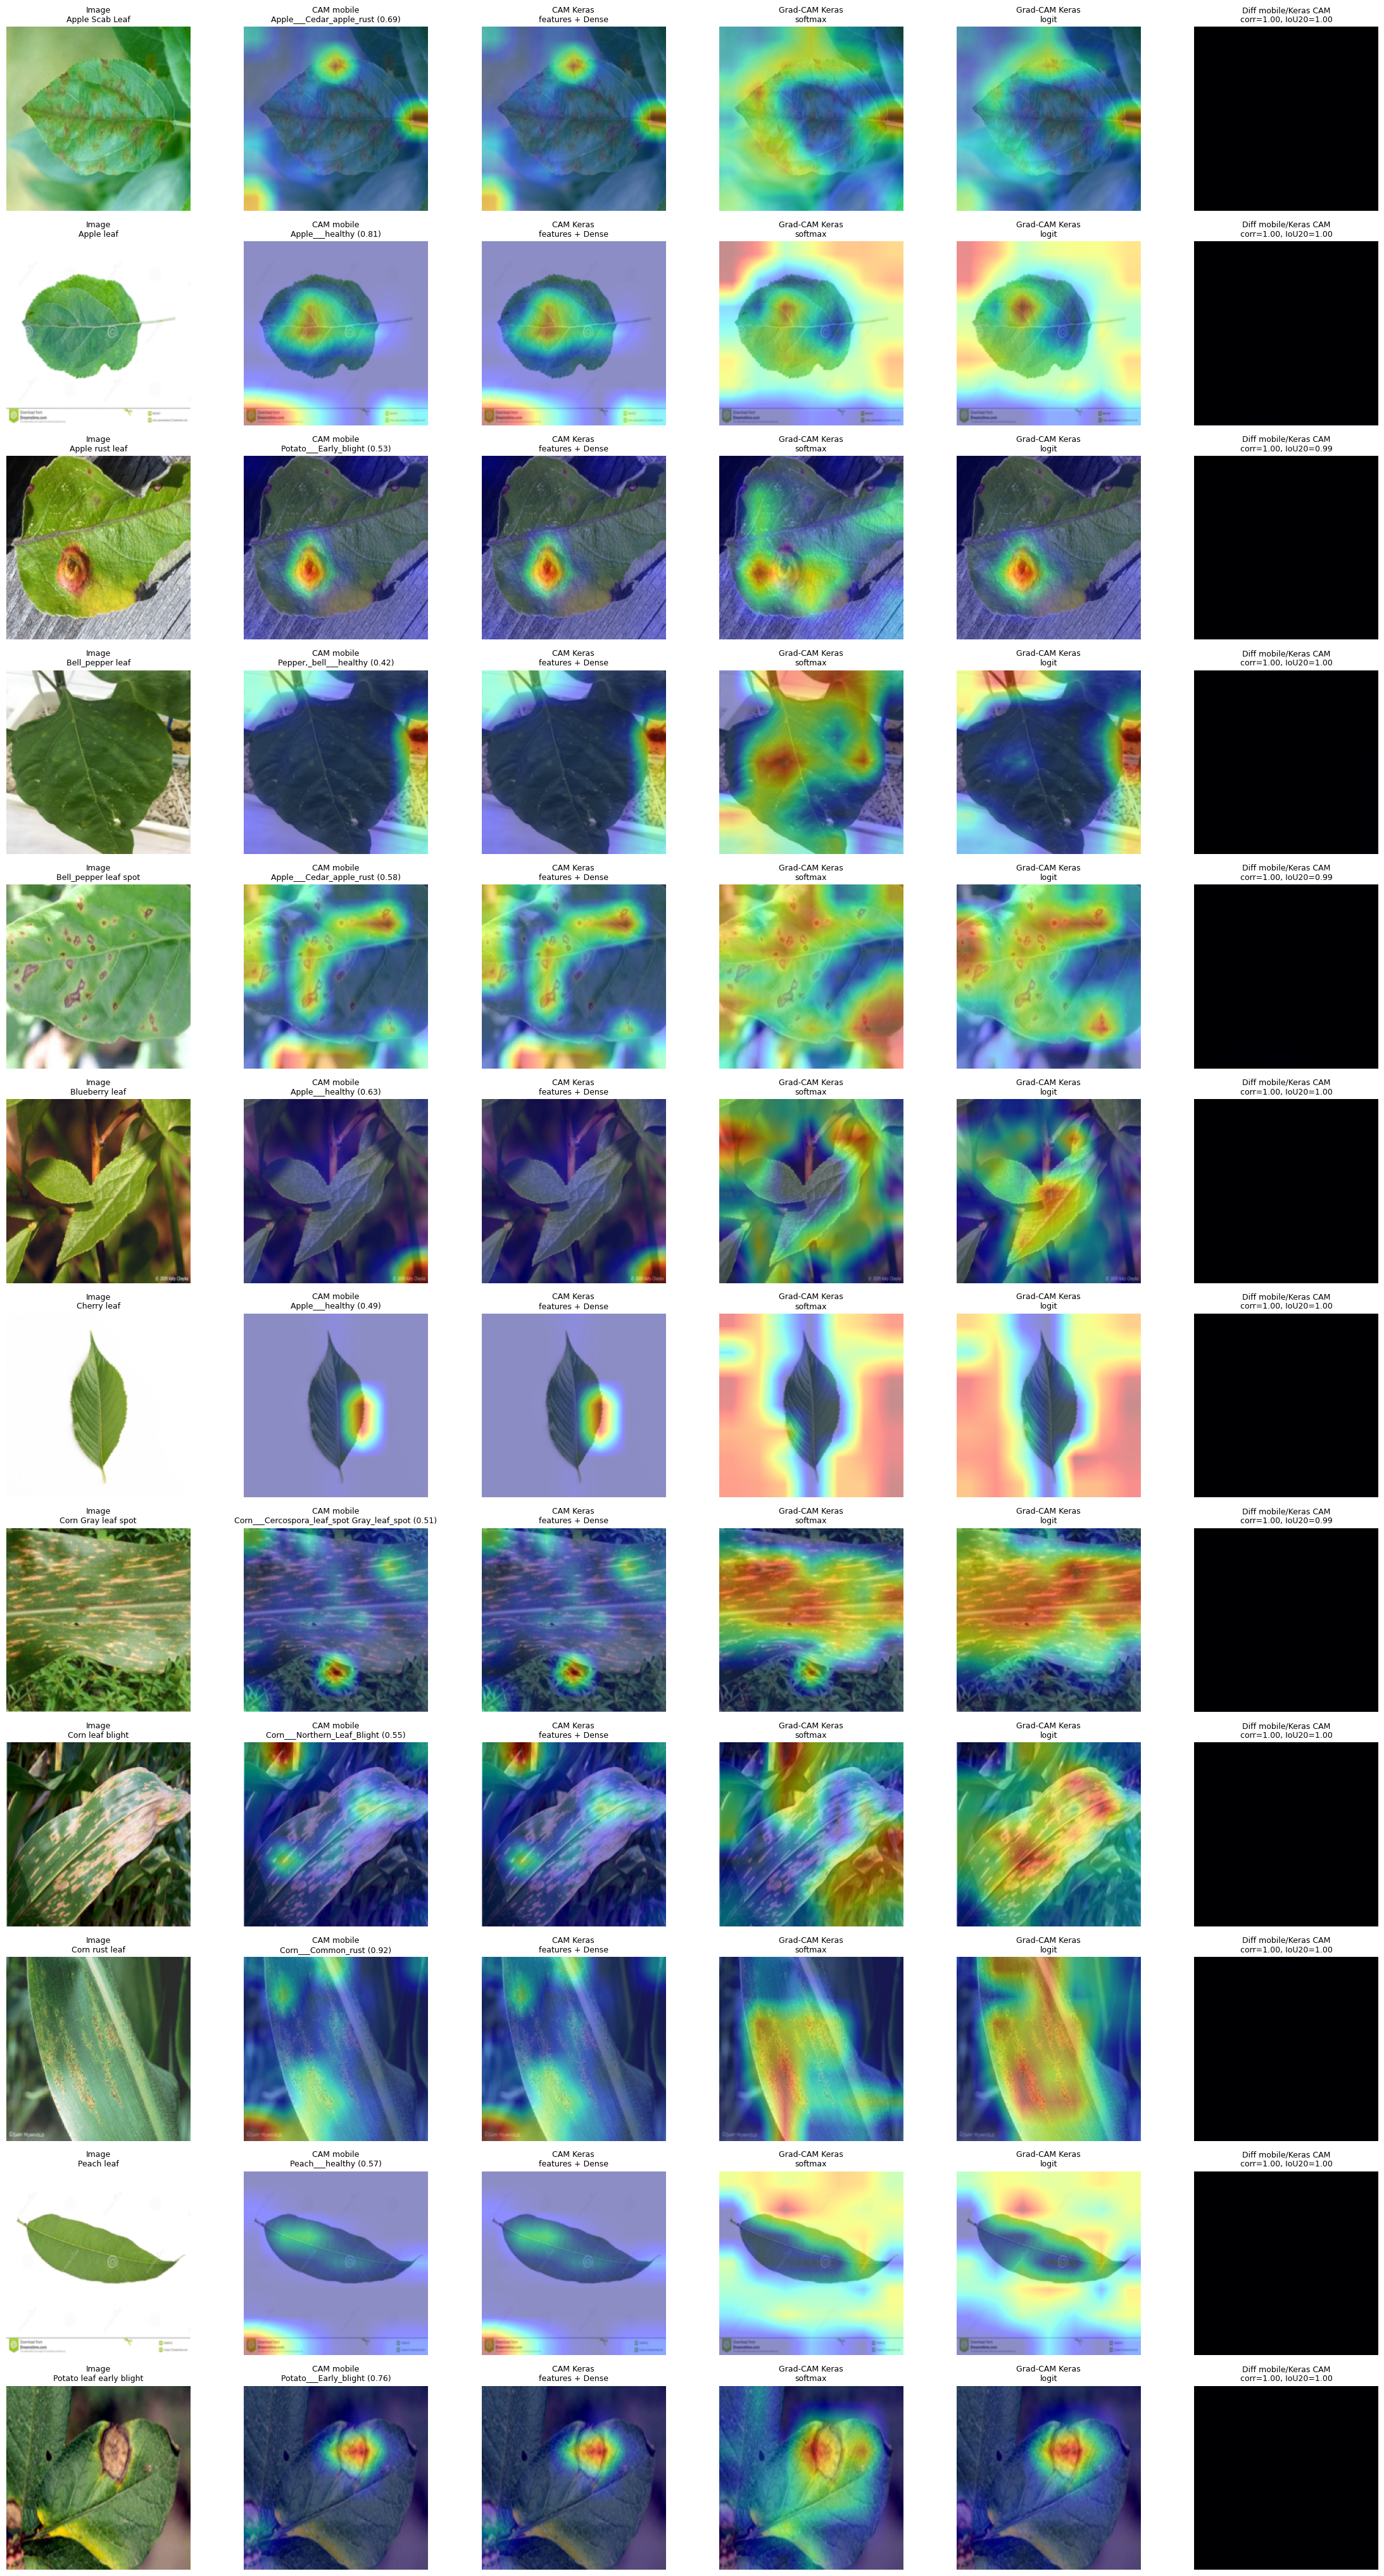

Figure sauvegardée : /home/leonard/UQAC/8INF934 - Atelier Pratique IA I/Projet/AgroScan/reports/jalon4_mobile_cam_vs_keras_gradcam.png


,path,plantdoc_class,keras_pred,keras_conf,tflite_pred,tflite_conf,argmax_match,mobile_vs_keras_cam_corr,mobile_vs_keras_cam_mae,mobile_vs_keras_cam_top20_iou,mobile_vs_gradcam_softmax_corr,mobile_vs_gradcam_softmax_mae,mobile_vs_gradcam_softmax_top20_iou,mobile_vs_gradcam_logits_corr,mobile_vs_gradcam_logits_mae,mobile_vs_gradcam_logits_top20_iou
0,data/plantdoc/test/Apple Scab Leaf/052609%20Ha...,Apple Scab Leaf,Apple___Cedar_apple_rust,0.695301,Apple___Cedar_apple_rust,0.692181,True,0.999990,0.000455,0.998009,0.519062,0.258167,0.220479,0.798940,0.106266,0.405405
1,data/plantdoc/test/Apple leaf/apple-leaf-98346...,Apple leaf,Apple___healthy,0.806523,Apple___healthy,0.806218,True,0.999991,0.000602,0.997015,-0.473848,0.424816,0.032086,-0.505416,0.419922,0.054423
2,data/plantdoc/test/Apple rust leaf/20130802_11...,Apple rust leaf,Potato___Early_blight,0.528802,Potato___Early_blight,0.527356,True,0.999998,0.000126,0.993648,0.474603,0.152936,0.344317,0.967057,0.023536,0.606531
3,data/plantdoc/test/Bell_pepper leaf/IMG_1629.J...,Bell_pepper leaf,"Pepper,_bell___healthy",0.408763,"Pepper,_bell___healthy",0.416518,True,0.999988,0.001054,0.998409,-0.396694,0.402985,0.071284,0.925040,0.103051,0.841680
4,data/plantdoc/test/Bell_pepper leaf spot/Bacte...,Bell_pepper leaf spot,Apple___Cedar_apple_rust,0.589250,Apple___Cedar_apple_rust,0.582906,True,0.999975,0.001139,0.994832,0.177625,0.311356,0.123726,0.315281,0.253718,0.332979
5,data/plantdoc/test/Blueberry leaf/vaccinium-an...,Blueberry leaf,Apple___healthy,0.623384,Apple___healthy,0.625683,True,0.999986,0.000602,0.995030,-0.448854,0.349447,0.009963,-0.098180,0.258848,0.155622
6,data/plantdoc/test/Cherry leaf/d7b79dbc0bca0eb...,Cherry leaf,Apple___healthy,0.490754,Apple___healthy,0.493584,True,0.999997,0.000187,0.998311,-0.424562,0.581947,0.000000,-0.421982,0.583886,0.007271
7,data/plantdoc/test/Corn Gray leaf spot/show_pi...,Corn Gray leaf spot,Corn___Cercospora_leaf_spot Gray_leaf_spot,0.512129,Corn___Cercospora_leaf_spot Gray_leaf_spot,0.510213,True,0.999984,0.000508,0.993445,0.192517,0.301662,0.076478,0.101887,0.389210,0.140455
8,data/plantdoc/test/Corn leaf blight/07c.jpg,Corn leaf blight,Corn___Northern_Leaf_Blight,0.549484,Corn___Northern_Leaf_Blight,0.547430,True,0.999994,0.000396,0.996618,-0.358622,0.323661,0.037742,-0.015403,0.362409,0.191924
9,data/plantdoc/test/Corn rust leaf/0796.39maize...,Corn rust leaf,Corn___Common_rust,0.918407,Corn___Common_rust,0.917991,True,0.999987,0.001174,0.997611,0.215839,0.220029,0.222710,0.133456,0.333768,0.260487


In [5]:
def plot_cam_comparison(paths, save_name='jalon4_mobile_cam_vs_keras_gradcam.png'):
    rows = []
    n = len(paths)
    fig, axes = plt.subplots(n, 6, figsize=(23, 3.4 * n))
    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, path in enumerate(paths):
        image = load_image_array(path)
        keras_probs = run_keras(image)
        tflite_probs, tflite_conv = run_tflite(image)
        keras_conv, keras_probs_from_head, keras_logits = keras_conv_and_predictions(image)

        keras_pred = int(np.argmax(keras_probs))
        tflite_pred = int(np.argmax(tflite_probs))
        class_index = tflite_pred

        mobile_cam7 = mobile_cam_from_conv(tflite_conv, class_index)
        keras_cam7 = keras_cam_from_conv(keras_conv, class_index)
        gradcam_softmax7 = keras_gradcam(image, class_index, logits=False)
        gradcam_logits7 = keras_gradcam(image, class_index, logits=True)

        mobile_cam = upsample_heatmap(mobile_cam7)
        keras_cam = upsample_heatmap(keras_cam7)
        gradcam_softmax = upsample_heatmap(gradcam_softmax7)
        gradcam_logits = upsample_heatmap(gradcam_logits7)
        diff_mobile_keras_cam = np.abs(mobile_cam - keras_cam)

        mobile_vs_keras_cam = heatmap_metrics(mobile_cam7, keras_cam7)
        mobile_vs_gradcam_softmax = heatmap_metrics(mobile_cam7, gradcam_softmax7)
        mobile_vs_gradcam_logits = heatmap_metrics(mobile_cam7, gradcam_logits7)

        rows.append({
            'path': str(path.relative_to(ROOT)),
            'plantdoc_class': path.parent.name,
            'keras_pred': labels[keras_pred],
            'keras_conf': float(keras_probs[keras_pred]),
            'tflite_pred': labels[tflite_pred],
            'tflite_conf': float(tflite_probs[tflite_pred]),
            'argmax_match': keras_pred == tflite_pred,
            'mobile_vs_keras_cam_corr': mobile_vs_keras_cam['corr'],
            'mobile_vs_keras_cam_mae': mobile_vs_keras_cam['mae'],
            'mobile_vs_keras_cam_top20_iou': mobile_vs_keras_cam['top20_iou'],
            'mobile_vs_gradcam_softmax_corr': mobile_vs_gradcam_softmax['corr'],
            'mobile_vs_gradcam_softmax_mae': mobile_vs_gradcam_softmax['mae'],
            'mobile_vs_gradcam_softmax_top20_iou': mobile_vs_gradcam_softmax['top20_iou'],
            'mobile_vs_gradcam_logits_corr': mobile_vs_gradcam_logits['corr'],
            'mobile_vs_gradcam_logits_mae': mobile_vs_gradcam_logits['mae'],
            'mobile_vs_gradcam_logits_top20_iou': mobile_vs_gradcam_logits['top20_iou'],
        })

        axes[row, 0].imshow(image.astype(np.uint8))
        axes[row, 0].set_title(f'Image\n{path.parent.name}', fontsize=9)
        axes[row, 0].axis('off')

        axes[row, 1].imshow(image.astype(np.uint8))
        axes[row, 1].imshow(mobile_cam, cmap='jet', alpha=0.45)
        axes[row, 1].set_title(f'CAM mobile\n{labels[tflite_pred]} ({tflite_probs[tflite_pred]:.2f})', fontsize=9)
        axes[row, 1].axis('off')

        axes[row, 2].imshow(image.astype(np.uint8))
        axes[row, 2].imshow(keras_cam, cmap='jet', alpha=0.45)
        axes[row, 2].set_title('CAM Keras\nfeatures + Dense', fontsize=9)
        axes[row, 2].axis('off')

        axes[row, 3].imshow(image.astype(np.uint8))
        axes[row, 3].imshow(gradcam_softmax, cmap='jet', alpha=0.45)
        axes[row, 3].set_title('Grad-CAM Keras\nsoftmax', fontsize=9)
        axes[row, 3].axis('off')

        axes[row, 4].imshow(image.astype(np.uint8))
        axes[row, 4].imshow(gradcam_logits, cmap='jet', alpha=0.45)
        axes[row, 4].set_title('Grad-CAM Keras\nlogit', fontsize=9)
        axes[row, 4].axis('off')

        axes[row, 5].imshow(diff_mobile_keras_cam, cmap='magma', vmin=0, vmax=1)
        axes[row, 5].set_title(
            f'Diff mobile/Keras CAM\n'
            f"corr={mobile_vs_keras_cam['corr']:.2f}, IoU20={mobile_vs_keras_cam['top20_iou']:.2f}",
            fontsize=9,
        )
        axes[row, 5].axis('off')

    plt.tight_layout()
    out = REPORT_DIR / save_name
    plt.savefig(out, dpi=180, bbox_inches='tight')
    plt.show()
    print('Figure sauvegardée :', out)
    return pd.DataFrame(rows)

comparison_df = plot_cam_comparison(sample_paths)
display(comparison_df)
comparison_df.to_csv(REPORT_DIR / 'jalon4_mobile_cam_vs_keras_gradcam.csv', index=False)


## 5. Lecture automatique des résultats

Les métriques ne remplacent pas la lecture visuelle, mais elles aident à repérer les cas où l'explication mobile diverge fortement du vrai Grad-CAM.

In [6]:
metric_cols = [
    'argmax_match',
    'mobile_vs_keras_cam_corr',
    'mobile_vs_keras_cam_mae',
    'mobile_vs_keras_cam_top20_iou',
    'mobile_vs_gradcam_softmax_corr',
    'mobile_vs_gradcam_softmax_mae',
    'mobile_vs_gradcam_softmax_top20_iou',
    'mobile_vs_gradcam_logits_corr',
    'mobile_vs_gradcam_logits_mae',
    'mobile_vs_gradcam_logits_top20_iou',
]
summary = comparison_df[metric_cols].agg(['mean', 'median', 'min', 'max'])
display(summary)

print('Lecture rapide :')
print(f"- accord Keras/TFLite argmax : {comparison_df['argmax_match'].mean()*100:.1f}%")
print(f"- corrélation médiane CAM mobile vs CAM Keras : {comparison_df['mobile_vs_keras_cam_corr'].median():.2f}")
print(f"- corrélation médiane CAM mobile vs Grad-CAM softmax : {comparison_df['mobile_vs_gradcam_softmax_corr'].median():.2f}")
print(f"- corrélation médiane CAM mobile vs Grad-CAM logit : {comparison_df['mobile_vs_gradcam_logits_corr'].median():.2f}")

worst = comparison_df.sort_values(
    ['mobile_vs_keras_cam_corr', 'mobile_vs_keras_cam_top20_iou'],
    ascending=[True, True],
).head(5)
print('\nCas où mobile diverge le plus de la CAM Keras :')
display(worst[[
    'plantdoc_class',
    'tflite_pred',
    'tflite_conf',
    'mobile_vs_keras_cam_corr',
    'mobile_vs_keras_cam_top20_iou',
    'mobile_vs_gradcam_softmax_corr',
    'mobile_vs_gradcam_logits_corr',
    'path',
]])


,argmax_match,mobile_vs_keras_cam_corr,mobile_vs_keras_cam_mae,mobile_vs_keras_cam_top20_iou,mobile_vs_gradcam_softmax_corr,mobile_vs_gradcam_softmax_mae,mobile_vs_gradcam_softmax_top20_iou,mobile_vs_gradcam_logits_corr,mobile_vs_gradcam_logits_mae,mobile_vs_gradcam_logits_top20_iou
mean,1.0,0.999990,0.000577,0.996174,-0.045330,0.326492,0.134583,0.206287,0.274164,0.294105
median,1.0,0.999991,0.000490,0.996271,-0.090498,0.317509,0.073881,0.117671,0.296308,0.226206
min,True,0.999975,0.000126,0.993445,-0.607734,0.152936,0.000000,-0.634825,0.023536,0.000898
max,True,0.999998,0.001174,0.998409,0.586703,0.581947,0.474871,0.967057,0.583886,0.841680


Lecture rapide :
- accord Keras/TFLite argmax : 100.0%
- corrélation médiane CAM mobile vs CAM Keras : 1.00
- corrélation médiane CAM mobile vs Grad-CAM softmax : -0.09
- corrélation médiane CAM mobile vs Grad-CAM logit : 0.12

Cas où mobile diverge le plus de la CAM Keras :


,plantdoc_class,tflite_pred,tflite_conf,mobile_vs_keras_cam_corr,mobile_vs_keras_cam_top20_iou,mobile_vs_gradcam_softmax_corr,mobile_vs_gradcam_logits_corr,path
4,Bell_pepper leaf spot,Apple___Cedar_apple_rust,0.582906,0.999975,0.994832,0.177625,0.315281,data/plantdoc/test/Bell_pepper leaf spot/Bacte...
7,Corn Gray leaf spot,Corn___Cercospora_leaf_spot Gray_leaf_spot,0.510213,0.999984,0.993445,0.192517,0.101887,data/plantdoc/test/Corn Gray leaf spot/show_pi...
5,Blueberry leaf,Apple___healthy,0.625683,0.999986,0.995030,-0.448854,-0.098180,data/plantdoc/test/Blueberry leaf/vaccinium-an...
9,Corn rust leaf,Corn___Common_rust,0.917991,0.999987,0.997611,0.215839,0.133456,data/plantdoc/test/Corn rust leaf/0796.39maize...
3,Bell_pepper leaf,"Pepper,_bell___healthy",0.416518,0.999988,0.998409,-0.396694,0.925040,data/plantdoc/test/Bell_pepper leaf/IMG_1629.J...


## 6. Interprétation des résultats

Les résultats montrent d'abord que l'implémentation mobile est cohérente avec le modèle Keras. Les cartes **CAM mobile** et **CAM Keras features + Dense** sont quasiment identiques sur les exemples observés. Cela indique que le TFLite exporte correctement les features `conv_1`, que les poids Dense embarqués sont dans le bon ordre, et que le preprocessing mobile est compatible avec celui du modèle Keras. Autrement dit, les écarts visibles ne viennent pas principalement d'un bug dans l'application.

La différence principale vient de la méthode d'explication. L'application mobile calcule une CAM forward : elle combine directement les activations convolutionnelles avec les poids de la classe prédite. Le Grad-CAM Keras, lui, utilise des gradients. Les cartes peuvent donc diverger, surtout avec une sortie softmax, car le gradient dépend aussi des classes concurrentes. C'est pour cela que le Grad-CAM softmax peut parfois être plus diffus ou regarder des zones différentes de la CAM mobile.

Le Grad-CAM logit est souvent la comparaison la plus utile côté recherche, car il retire une partie de l'effet de compétition introduit par la softmax. Dans plusieurs cas, il semble plus proche de ce que l'on attend visuellement que le Grad-CAM softmax. Cependant, même le Grad-CAM logit reste imparfait si le modèle se trompe ou s'il s'appuie sur des indices de contexte présents dans le fond.

Lecture qualitative des exemples :

- quand la prédiction est correcte et la feuille bien cadrée, les cartes sont généralement défendables ;
- sur certains cas de maladies visibles, la CAM mobile localise une zone pertinente, mais parfois trop localisée par rapport aux symptômes étendus ;
- lorsque le modèle prédit une mauvaise classe, les cartes expliquent cette mauvaise décision et ne doivent pas être interprétées comme une localisation fiable de la maladie ;
- plusieurs exemples montrent encore une attention portée au fond ou aux bords de la feuille, ce qui confirme que le modèle n'est pas totalement robuste aux images terrain.

Conclusion pour l'application mobile : l'explication embarquée peut être conservée, mais elle doit être présentée comme une indication visuelle approximative. Il vaut mieux employer des formulations prudentes comme **« zones influentes »** ou **« zones utilisées par le modèle »**, plutôt que de promettre une localisation exacte des symptômes. Cette visualisation aide à rendre le diagnostic plus transparent, mais elle ne constitue pas une preuve que la maladie se trouve précisément dans les zones rouges.

Conclusion pour la suite du projet : le problème restant est moins l'export mobile que la robustesse du modèle. Les pistes prioritaires sont donc de continuer à réduire l'influence du fond, par exemple avec la segmentation/crop de feuille, des augmentations plus fortes sur les arrière-plans, ou un masquage de la heatmap par la feuille avant affichage. Il serait aussi pertinent de garder le Grad-CAM logit comme référence d'audit dans les notebooks, car il semble plus stable que le Grad-CAM softmax pour analyser ce modèle.
